# Extinction vs distance toward w51

In [7]:
from astropy.table import Table
from astropy.io import ascii

In [3]:
import requests

In [11]:
resp = requests.get("http://argonaut.skymaps.info/api/v2/interactive/bayestar2019/lostable?lon=49.8&lat=-0.4&coordsys=gal")

In [12]:
print(resp.text)

#
# Line-of-Sight Reddening Results
# ===============================
#
# # Galactic coordinates (in degrees):
#     l = 49.8000
#     b = -0.4000
#
# Reliable distance moduli:
#     min: 7.25
#     max: 12.58
# Fit converged: True
#
# The table contains E(g-r) in magnitudes out to the specified distance moduli.
# Each column corresponds to a different distance modulus, and each row
# corresponds to a different sample. The first sample is the best fit, while
# the following samples are drawn from the posterior distribution of
# distance-reddening profiles.
#
# See Green et al. (2014, 2015, 2018, 2019) for a detailed description
# of how the line-of-sight reddening is computed, and for coefficients
# to convert E(g-r) into extinction in different bands. To convert to
# extinction in other bands, use coefficients in Table 6
# of Schlafly & Finkbeiner (2011).
#
 SampleNo | DistanceModulus
          |  4.00  4.12  4.25  4.38  4.50  4.62  4.75  4.88  5.00  5.12  5.25  5.38  5.50  5.62  5.75

In [15]:
import numpy as np

In [16]:
egr = np.array("0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.000 0.387 0.387 0.387 0.387 0.387 0.396 0.396 0.405 0.414 0.414 0.414 0.423 0.423 0.604 0.604 0.640 0.676 0.676 0.685 0.694 0.694 0.703 0.703 0.703 0.712 0.712 0.757 0.775 0.784 0.802 0.802 0.802 0.802 0.955 0.955 0.955 0.955 0.991 1.000 1.009 1.009 1.018 1.027 1.027 1.027 1.063 1.072 1.099 1.451 1.451 1.451 1.460 1.460 1.460 1.460 2.072 2.072 2.072 2.072 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.081 2.090 2.090 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099 2.099".split(), dtype='float')

In [17]:
dm = np.array("4.00  4.12  4.25  4.38  4.50  4.62  4.75  4.88  5.00  5.12  5.25  5.38  5.50  5.62  5.75  5.88  6.00  6.12  6.25  6.38  6.50  6.62  6.75  6.88  7.00  7.12  7.25  7.38  7.50  7.62  7.75  7.88  8.00  8.12  8.25  8.38  8.50  8.62  8.75  8.88  9.00  9.12  9.25  9.38  9.50  9.62  9.75  9.88 10.00 10.12 10.25 10.38 10.50 10.62 10.75 10.88 11.00 11.12 11.25 11.38 11.50 11.62 11.75 11.88 12.00 12.12 12.25 12.38 12.50 12.62 12.75 12.88 13.00 13.12 13.25 13.38 13.50 13.62 13.75 13.88 14.00 14.12 14.25 14.38 14.50 14.62 14.75 14.88 15.00 15.12 15.25 15.38 15.50 15.62 15.75 15.88 16.00 16.12 16.25 16.38 16.50 16.62 16.75 16.88 17.00 17.12 17.25 17.38 17.50 17.62 17.75 17.88 18.00 18.12 18.25 18.38 18.50 18.62 18.75 18.88".split(), dtype='float')

In [18]:
%matplotlib inline
import pylab as pl

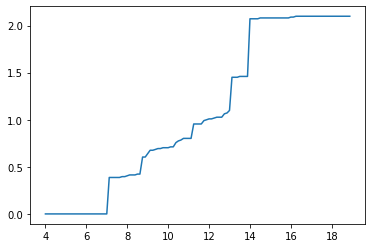

In [19]:
pl.plot(dm, egr)

In [20]:
import dust_extinction

In [21]:
from dust_extinction.averages import GCC09_MWAvg

In [24]:
from astropy import units as u

In [25]:
from astroquery.svo_fps import SvoFps

In [30]:
SvoFps.get_filter_list('PAN-STARRS')

FilterProfileService,filterID,WavelengthUnit,WavelengthUCD,PhotSystem,DetectorType,Band,Instrument,Facility,ProfileReference,CalibrationReference,Description,Comments,WavelengthRef,WavelengthMean,WavelengthEff,WavelengthMin,WavelengthMax,WidthEff,WavelengthCen,WavelengthPivot,WavelengthPeak,WavelengthPhot,FWHM,Fsun,PhotCalID,MagSys,ZeroPoint,ZeroPointUnit,Mag0,ZeroPointType,AsinhSoft,TrasmissionCurve
,,,,,,,,,,,,,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,AA,erg / (A s cm2),,,Jy,,,,,
object,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,object,object,float64,object,float64,object,float64,object
ivo://svo/fps,PAN-STARRS/PS1.g,Angstrom,em.wl,PAN-STARRS,1,g,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 g filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,4849.1149388631,4900.1230736441,4810.1596079294,3949.5019343987,5593.8722819594,1053.0808667895,4936.0084481164,4849.1149388631,5390.0,4844.9614853056,1148.6617893445,189.41365665118,PAN-STARRS/PS1.g/Vega,Vega,3964.0298373521,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.g
ivo://svo/fps,PAN-STARRS/PS1.r,Angstrom,em.wl,PAN-STARRS,1,,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 r filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,6201.2000304365,6241.274452634,6155.4659814728,5391.1116707617,7038.0787142857,1252.4068800721,6206.1685931728,6201.2000304365,6540.0,6182.3767876283,1397.7332085088,167.67415150919,PAN-STARRS/PS1.r/Vega,Vega,3173.0162470114,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.r
ivo://svo/fps,PAN-STARRS/PS1.w,Angstrom,em.wl,PAN-STARRS,1,,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 w filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,6285.9105687594,6579.2208409631,5980.702689485,3986.1905236908,8346.206746988,2561.7294515434,6822.4848444143,6285.9105687594,7980.0,6190.622271892,2633.0128853728,153.00145066247,PAN-STARRS/PS1.w/Vega,Vega,3231.3347748642,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.w
ivo://svo/fps,PAN-STARRS/PS1.open,Angstrom,em.wl,PAN-STARRS,1,,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 open filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,6943.7616548862,7461.3104352044,6431.865942007,3800.0,10808.204566636,3985.0189913126,7642.3343771139,6943.7616548862,8670.0,6800.750768629,4098.0995319442,129.78784250303,PAN-STARRS/PS1.open/Vega,Vega,3017.1297794583,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.open
ivo://svo/fps,PAN-STARRS/PS1.i,Angstrom,em.wl,PAN-STARRS,1,,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 i filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,7534.9604644213,7563.7581578246,7503.0304998466,6783.1724340176,8306.2380990737,1206.6247917955,7553.4838532432,7534.9604644213,7980.0,7522.1893050592,1292.393757412,125.58006405556,PAN-STARRS/PS1.i/Vega,Vega,2575.3555343428,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.i
ivo://svo/fps,PAN-STARRS/PS1.z,Angstrom,em.wl,PAN-STARRS,1,z,PAN-STARRS,PAN-STARRS,http://ipp.ifa.hawaii.edu/ps1.filters/,,PS1 z filter,Including the nominal 1.2 airmasses of the Pan-STARRS1 standard atmospheric extinction.,8674.2022460152,8690.1011083385,8668.3635610343,8030.6815365551,9350.4721030043,997.71954608564,8704.7524811377,8674.2022460152,8400.0,8679.0288357167,1038.817168149,96.388420646256,PAN-STARRS/PS1.z/Vega,Vega,2261.8137088659,Jy,0.0,Pogson,0.0,http://svo2.cab.inta-csic.es//theory/fps/fps.php?ID=PAN-STARRS/PS1.z
ivo://svo/fps,PAN-STARRS/PS1.y,Angstrom,em.wl,PAN-STARRS,1,y,PAN-

In [36]:
av = egr / (GCC09_MWAvg()(4900*u.AA) -  GCC09_MWAvg()(6201*u.AA))

In [45]:
dkpc = 10**(dm/5) * 10 / 1e3

In [46]:
dm

array([ 4.  ,  4.12,  4.25,  4.38,  4.5 ,  4.62,  4.75,  4.88,  5.  ,
        5.12,  5.25,  5.38,  5.5 ,  5.62,  5.75,  5.88,  6.  ,  6.12,
        6.25,  6.38,  6.5 ,  6.62,  6.75,  6.88,  7.  ,  7.12,  7.25,
        7.38,  7.5 ,  7.62,  7.75,  7.88,  8.  ,  8.12,  8.25,  8.38,
        8.5 ,  8.62,  8.75,  8.88,  9.  ,  9.12,  9.25,  9.38,  9.5 ,
        9.62,  9.75,  9.88, 10.  , 10.12, 10.25, 10.38, 10.5 , 10.62,
       10.75, 10.88, 11.  , 11.12, 11.25, 11.38, 11.5 , 11.62, 11.75,
       11.88, 12.  , 12.12, 12.25, 12.38, 12.5 , 12.62, 12.75, 12.88,
       13.  , 13.12, 13.25, 13.38, 13.5 , 13.62, 13.75, 13.88, 14.  ,
       14.12, 14.25, 14.38, 14.5 , 14.62, 14.75, 14.88, 15.  , 15.12,
       15.25, 15.38, 15.5 , 15.62, 15.75, 15.88, 16.  , 16.12, 16.25,
       16.38, 16.5 , 16.62, 16.75, 16.88, 17.  , 17.12, 17.25, 17.38,
       17.5 , 17.62, 17.75, 17.88, 18.  , 18.12, 18.25, 18.38, 18.5 ,
       18.62, 18.75, 18.88])

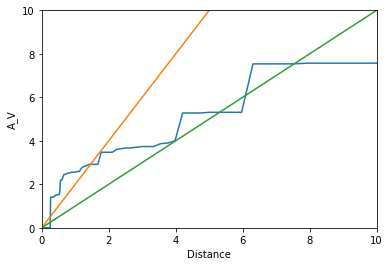

In [55]:
pl.plot(dkpc, av)
pl.plot(dkpc, dkpc*2, label='2 mags per kpc')
pl.plot(dkpc, dkpc*1, label='1 mags per kpc')

pl.xlabel("Distance")
pl.xlim(0, 10)
pl.ylabel("A_V")
pl.ylim(0,10);